In [48]:
import numpy as np
import pandas as pd 

In [49]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/walmart-sales-and-demand-forecasting/train.csv
/kaggle/input/walmart-sales-and-demand-forecasting/final_walmart_sales_dataset.csv
/kaggle/input/amazon-review-dataset/Amazon_Reviews.csv


In [50]:
import pandas as pd

final_df = pd.read_csv(
    "/kaggle/input/walmart-sales-and-demand-forecasting/final_walmart_sales_dataset.csv"
)

train_df = pd.read_csv(
    "/kaggle/input/walmart-sales-and-demand-forecasting/train.csv"
)

print(final_df.head())
print(train_df.head())
print("Final dataset shape:", final_df.shape)
print("Train dataset shape:", train_df.shape)


   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  05-02-2010        42.31       2.572        NaN        NaN   
1      1  12-02-2010        38.51       2.548        NaN        NaN   
2      1  19-02-2010        39.93       2.514        NaN        NaN   
3      1  26-02-2010        46.63       2.561        NaN        NaN   
4      1  05-03-2010        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  \
0        NaN        NaN        NaN  211.096358         8.106      False   
1        NaN        NaN        NaN  211.242170         8.106       True   
2        NaN        NaN        NaN  211.289143         8.106      False   
3        NaN        NaN        NaN  211.319643         8.106      False   
4        NaN        NaN        NaN  211.350143         8.106      False   

                 name    city state  latitude  longitude  
0  Conway Supercenter  Conway    AR  35.10866 -92.436905  
1  C

In [51]:
print(train_df["Date"].dtype)
print(final_df["Date"].dtype)


object
object


In [52]:
# Convert BOTH Date columns explicitly
train_df["Date"] = pd.to_datetime(train_df["Date"], dayfirst=True, errors="coerce")
final_df["Date"] = pd.to_datetime(final_df["Date"], dayfirst=True, errors="coerce")
print(train_df["Date"].dtype)
print(final_df["Date"].dtype)

print(train_df["Date"].isna().sum())
print(final_df["Date"].isna().sum())


datetime64[ns]
datetime64[ns]
253414
0


In [53]:
train_df = pd.read_csv(
    f"{ "/kaggle/input/walmart-sales-and-demand-forecasting"}/train.csv",
    dtype={"Date": str}  # force Date as string
)
train_df["Date"] = train_df["Date"].str.strip()
train_df["Date"] = pd.to_datetime(
    train_df["Date"],
    infer_datetime_format=True,
    errors="coerce"
)
print(train_df["Date"].isna().sum())


0


/tmp/ipykernel_55/1704513058.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  train_df["Date"] = pd.to_datetime(


In [54]:
merged_df = pd.merge(
    train_df,
    final_df,
    on=["Store", "Date"],
    how="left"
)

print("Merged shape:", merged_df.shape)
print(merged_df.head())


Merged shape: (421570, 20)
   Store  Dept       Date  Weekly_Sales  IsHoliday_x  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50        False        42.31       2.572   
1      1     1 2010-02-12      46039.49         True        38.51       2.548   
2      1     1 2010-02-19      41595.55        False        39.93       2.514   
3      1     1 2010-02-26      19403.54        False        46.63       2.561   
4      1     1 2010-03-05      21827.90        False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unemployment  IsHoliday_y                name    c

In [55]:
# Save merged dataset so Kaggle can download it
merged_df.to_csv("/kaggle/working/walmart_master_dataset.csv", index=False)

print("Saved successfully!")


Saved successfully!


data understanding****

In [56]:
print(merged_df.shape)
print(merged_df.dtypes)
print(merged_df.isnull().sum())
print(merged_df["Store"].nunique())
print(merged_df["Dept"].nunique())
print(merged_df.describe()
)



(421570, 20)
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday_x               bool
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday_y               bool
name                    object
city                    object
state                   object
latitude               float64
longitude              float64
dtype: object
Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
name    

In [57]:
merged_df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'name', 'city',
       'state', 'latitude', 'longitude'],
      dtype='object')

In [58]:
merged_df = merged_df.loc[:, ~merged_df.columns.duplicated()]
merged_df.columns



Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'name', 'city',
       'state', 'latitude', 'longitude'],
      dtype='object')

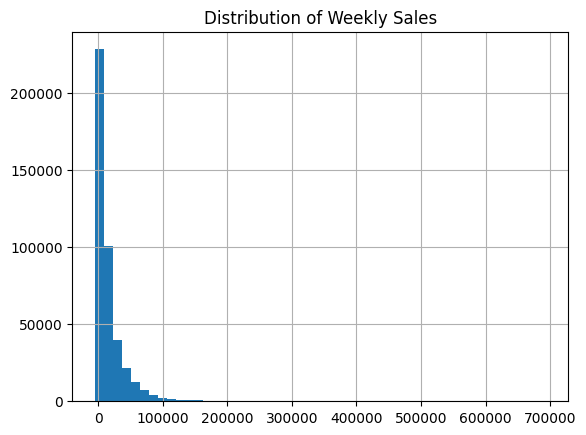

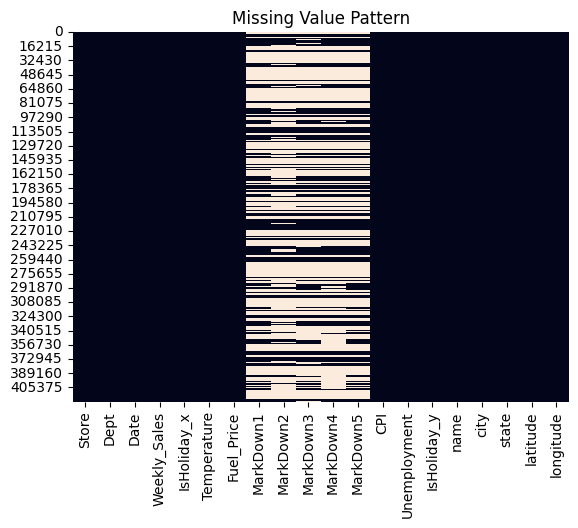

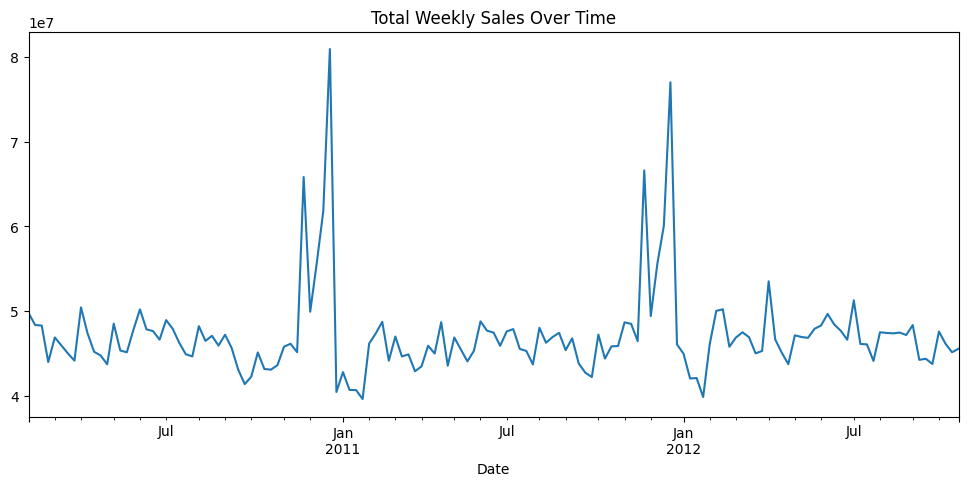

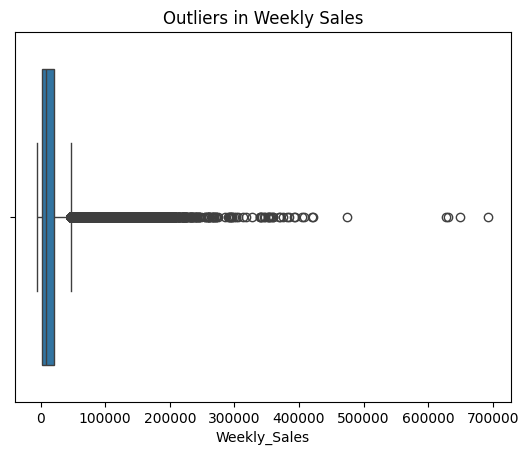

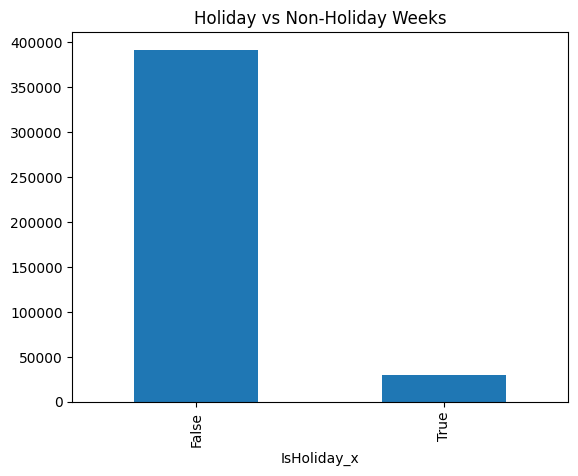

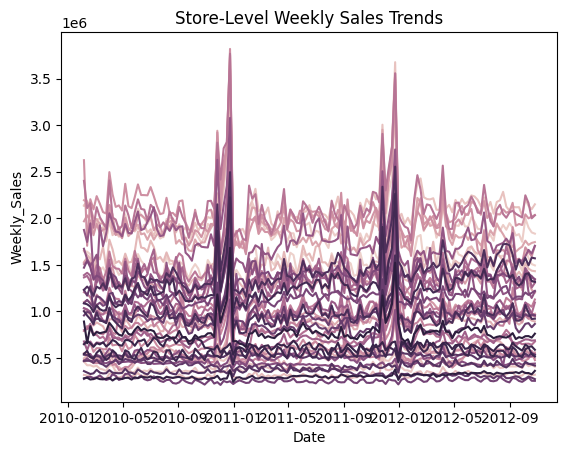

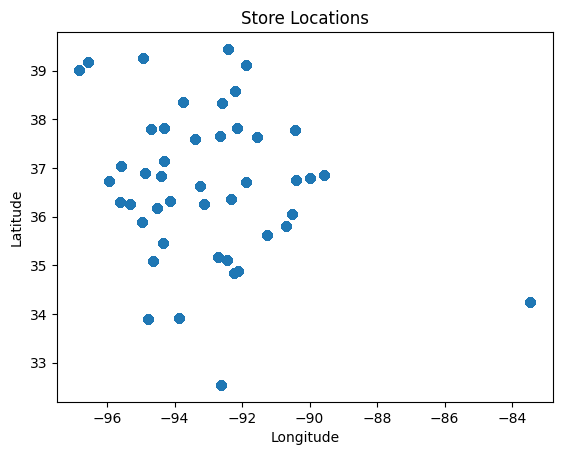

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

merged_df["Weekly_Sales"].hist(bins=50)
plt.title("Distribution of Weekly Sales")
plt.show()
#heatmap

sns.heatmap(merged_df.isnull(), cbar=False)
plt.title("Missing Value Pattern")
plt.show()
store_sales = merged_df.groupby("Date")["Weekly_Sales"].sum()
#time series
store_sales.plot(figsize=(12,5))
plt.title("Total Weekly Sales Over Time")
plt.show()
#outliers
sns.boxplot(x=merged_df["Weekly_Sales"])
plt.title("Outliers in Weekly Sales")
plt.show()
#barplot
merged_df["IsHoliday_x"].value_counts().plot(kind="bar")
plt.title("Holiday vs Non-Holiday Weeks")
plt.show()
#aggregation
store_trend = merged_df.groupby(["Store", "Date"])["Weekly_Sales"].sum().reset_index()

sns.lineplot(data=store_trend, x="Date", y="Weekly_Sales", hue="Store", legend=False)
plt.title("Store-Level Weekly Sales Trends")
plt.show()
#scatter plot
plt.scatter(merged_df["longitude"], merged_df["latitude"])
plt.title("Store Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()




“The dataset contains 421,570 weekly sales records across 45 Walmart stores and 81 departments from 2010 to 2012. It includes sales, economic indicators, promotional markdowns, and geospatial information. While most features are complete, markdown variables contain significant missing values. Sales exhibit high variability, indicating strong seasonal and promotional effects.”

In [63]:
print(merged_df.columns.tolist())


['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'name', 'city', 'state', 'latitude', 'longitude']


In [66]:
markdown_cols = ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]
merged_df[markdown_cols] = merged_df[markdown_cols].fillna(0)
print(merged_df.isnull().sum())
print(merged_df.head())


Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday_x     0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday_y     0
name            0
city            0
state           0
latitude        0
longitude       0
dtype: int64
   Store  Dept       Date  Weekly_Sales  IsHoliday_x  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50        False        42.31       2.572   
1      1     1 2010-02-12      46039.49         True        38.51       2.548   
2      1     1 2010-02-19      41595.55        False        39.93       2.514   
3      1     1 2010-02-26      19403.54        False        46.63       2.561   
4      1     1 2010-03-05      21827.90        False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        0.0        0.0        0.0        0.0        0.0  211.096358

In [67]:
print(merged_df.columns.tolist())

['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'name', 'city', 'state', 'latitude', 'longitude']


In [68]:
merged_df["Weekly_Sales"] = merged_df["Weekly_Sales"].clip(lower=0)
merged_df.drop_duplicates(inplace=True)
merged_df.columns = (
    merged_df.columns
    .str.lower()
    .str.replace(" ", "_")
)
print(merged_df.columns.tolist())
merged_df["weekly_sales_log"] = np.log1p(merged_df["weekly_sales"])
print(merged_df.columns.tolist






['store', 'dept', 'date', 'weekly_sales', 'isholiday_x', 'temperature', 'fuel_price', 'markdown1', 'markdown2', 'markdown3', 'markdown4', 'markdown5', 'cpi', 'unemployment', 'isholiday_y', 'name', 'city', 'state', 'latitude', 'longitude']
['store', 'dept', 'date', 'weekly_sales', 'isholiday_x', 'temperature', 'fuel_price', 'markdown1', 'markdown2', 'markdown3', 'markdown4', 'markdown5', 'cpi', 'unemployment', 'isholiday_y', 'name', 'city', 'state', 'latitude', 'longitude', 'weekly_sales_log']


In [69]:
merged_df.isnull().sum()
merged_df.dtypes
merged_df.describe()
merged_df.head()


,store,dept,date,weekly_sales,isholiday_x,temperature,fuel_price,markdown1,markdown2,markdown3,...,markdown5,cpi,unemployment,isholiday_y,name,city,state,latitude,longitude,weekly_sales_log
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,0.0,211.096358,8.106,False,Conway Supercenter,Conway,AR,35.10866,-92.436905,10.123647
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,0.0,211.242170,8.106,True,Conway Supercenter,Conway,AR,35.10866,-92.436905,10.737277
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,0.0,211.289143,8.106,False,Conway Supercenter,Conway,AR,35.10866,-92.436905,10.635773
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,0.0,211.319643,8.106,False,Conway Supercenter,Conway,AR,35.10866,-92.436905,9.873262
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,0.0,211.350143,8.106,False,Conway Supercenter,Conway,AR,35.10866,-92.436905,9.990990


data transformation

In [70]:
merged_df["year"] = merged_df["date"].dt.year
merged_df["month"] = merged_df["date"].dt.month
merged_df["week"] = merged_df["date"].dt.isocalendar().week
merged_df["quarter"] = merged_df["date"].dt.quarter
merged_df[["date", "year", "month", "week", "quarter"]].head()



,date,year,month,week,quarter
0,2010-02-05,2010,2,5,1
1,2010-02-12,2010,2,6,1
2,2010-02-19,2010,2,7,1
3,2010-02-26,2010,2,8,1
4,2010-03-05,2010,3,9,1


In [72]:
store_level_df = (
    merged_df
    .groupby(["store", "date", "city", "state", "latitude", "longitude"])
    .agg({
        "weekly_sales": "sum",
        "temperature": "mean",
        "fuel_price": "mean",
        "cpi": "mean",
        "unemployment": "mean",
        "isholiday_x": "max"
    })
    .reset_index()
)


In [73]:
merged_df["lag_1"] = (
    merged_df
    .groupby(["store", "dept"])["weekly_sales"]
    .shift(1)
)


In [74]:
merged_df["rolling_4w"] = (
    merged_df
    .groupby(["store", "dept"])["weekly_sales"]
    .rolling(4)
    .mean()
    .reset_index(level=[0,1], drop=True)
)


In [75]:
merged_df.shape
merged_df.head()



,store,dept,date,weekly_sales,isholiday_x,temperature,fuel_price,markdown1,markdown2,markdown3,...,state,latitude,longitude,weekly_sales_log,year,month,week,quarter,lag_1,rolling_4w
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,AR,35.10866,-92.436905,10.123647,2010,2,5,1,NaN,NaN
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,AR,35.10866,-92.436905,10.737277,2010,2,6,1,24924.50,NaN
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,AR,35.10866,-92.436905,10.635773,2010,2,7,1,46039.49,NaN
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,AR,35.10866,-92.436905,9.873262,2010,2,8,1,41595.55,32990.77
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,AR,35.10866,-92.436905,9.990990,2010,3,9,1,19403.54,32216.62


In [76]:
merged_df[["lag_1","rolling_4w"]] = merged_df[["lag_1","rolling_4w"]].fillna(0)
merged_df.head()


,store,dept,date,weekly_sales,isholiday_x,temperature,fuel_price,markdown1,markdown2,markdown3,...,state,latitude,longitude,weekly_sales_log,year,month,week,quarter,lag_1,rolling_4w
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,AR,35.10866,-92.436905,10.123647,2010,2,5,1,0.00,0.00
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,AR,35.10866,-92.436905,10.737277,2010,2,6,1,24924.50,0.00
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,AR,35.10866,-92.436905,10.635773,2010,2,7,1,46039.49,0.00
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,AR,35.10866,-92.436905,9.873262,2010,2,8,1,41595.55,32990.77
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,AR,35.10866,-92.436905,9.990990,2010,3,9,1,19403.54,32216.62


In [77]:
store_level_df.head()


,store,date,city,state,latitude,longitude,weekly_sales,temperature,fuel_price,cpi,unemployment,isholiday_x
0,1,2010-02-05,Conway,AR,35.10866,-92.436905,1643690.90,42.31,2.572,211.096358,8.106,False
1,1,2010-02-12,Conway,AR,35.10866,-92.436905,1641957.44,38.51,2.548,211.242170,8.106,True
2,1,2010-02-19,Conway,AR,35.10866,-92.436905,1612831.17,39.93,2.514,211.289143,8.106,False
3,1,2010-02-26,Conway,AR,35.10866,-92.436905,1409727.59,46.63,2.561,211.319643,8.106,False
4,1,2010-03-05,Conway,AR,35.10866,-92.436905,1554806.68,46.50,2.625,211.350143,8.106,False


In [79]:
test_store = 1
test_date = merged_df["date"].iloc[0]

merged_df[
    (merged_df["store"] == test_store) &
    (merged_df["date"] == test_date)
]["weekly_sales"].sum()


np.float64(1643690.9)

In [80]:
store_level_df[
    (store_level_df["store"] == test_store) &
    (store_level_df["date"] == test_date)
]["weekly_sales"].values


array([1643690.9])

In [81]:
merged_df.to_csv("/kaggle/working/walmart_finalone_dataset.csv", index=False)

print("Saved successfully!")


Saved successfully!


In [85]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Time series
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [82]:
STORE_ID = 12
DEPT_ID = 5

df = merged_df[
    (merged_df["store"] == STORE_ID) &
    (merged_df["dept"] == DEPT_ID)
].copy()

df.set_index("date", inplace=True)

print(df.shape)


(143, 26)


In [83]:
train = df.iloc[:-8]
test  = df.iloc[-8:]

print("Train weeks:", len(train))
print("Test weeks :", len(test))


Train weeks: 135
Test weeks : 8


In [86]:
sarima_model = SARIMAX(
    train["weekly_sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,52)
)

sarima_fit = sarima_model.fit()
sarima_pred = sarima_fit.forecast(steps=8)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [87]:
print(sarima_pred)


2012-09-07    18774.955853
2012-09-14    22198.858306
2012-09-21    21005.870368
2012-09-28    22290.196618
2012-10-05    27194.578043
2012-10-12    25305.432837
2012-10-19    25922.829669
2012-10-26    26513.990401
Freq: W-FRI, Name: predicted_mean, dtype: float64


In [89]:
features = ["lag_1", "rolling_4w", "isholiday_x"]

X_train = train[features]
y_train = train["weekly_sales"]

X_test = test[features]
y_test = test["weekly_sales"]


In [90]:
ml_model = RandomForestRegressor(n_estimators=200, random_state=42)
ml_model.fit(X_train, y_train)

ml_pred = ml_model.predict(X_test)


In [91]:
sarima_error = mean_absolute_error(y_test, sarima_pred)
ml_error = mean_absolute_error(y_test, ml_pred)

print("SARIMA MAE:", sarima_error)
print("ML MAE:", ml_error)


SARIMA MAE: 2699.0540046243773
ML MAE: 2608.8246562499903


In [93]:
final_pred = 0.6 * ml_pred + 0.4 * sarima_pred


In [94]:
print(final_pred)


2012-09-07    18460.668951
2012-09-14    20244.119112
2012-09-21    20925.952697
2012-09-28    20647.601357
2012-10-05    26398.291557
2012-10-12    25050.512165
2012-10-19    24474.051658
2012-10-26    24886.354470
Freq: W-FRI, Name: predicted_mean, dtype: float64


In [95]:
last_actual = y_train.iloc[-1]

trend = "Increasing" if final_pred[-1] > last_actual else "Decreasing"
print("Trend:", trend)


Trend: Increasing


/tmp/ipykernel_55/3663640121.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  trend = "Increasing" if final_pred[-1] > last_actual else "Decreasing"


In [96]:
confidence = round(ml_model.score(X_test, y_test) * 100, 2)
print("Confidence:", confidence, "%")


Confidence: 1.18 %


In [98]:
merged_df["week"] = merged_df["date"].dt.isocalendar().week
merged_df["month"] = merged_df["date"].dt.month
merged_df["year"] = merged_df["date"].dt.year
features = ["lag_1", "rolling_4w", "isholiday_x", "week", "month"]

X_train = train[features]
y_train = train["weekly_sales"]

X_test = test[features]
y_test = test["weekly_sales"]
ml_model = RandomForestRegressor(n_estimators=300, random_state=42)

ml_model.fit(X_train, y_train)
# ---- NEW PREDICTIONS (MOST IMPORTANT LINE) ----
ml_pred = ml_model.predict(X_test)

# ---- RECOMPUTE METRICS ----
from sklearn.metrics import mean_absolute_error

print("New ML MAE:", mean_absolute_error(y_test, ml_pred))
print("New Confidence:", round(ml_model.score(X_test, y_test)*100,2), "%")




New ML MAE: 3158.6755500000027
New Confidence: -11.14 %
